<a href="https://colab.research.google.com/github/avinashaathi/Machine-Learning/blob/main/Capstone%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully

First 5 Records:
   PM2.5  PM10    CO  NO2  SO2  O3    AQI
0    122   270  0.71   42   49  70  164.3
1    199    80  0.45   18   22  28  121.2
2    112    67  0.18   52   40  18   84.7
3     34   174  1.22   57   37  37  109.0
4    126   240  1.39   48   34  61  169.3

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 19445.2168 - mae: 134.8930 - val_loss: 20508.6797 - val_mae: 138.3645
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 19341.5684 - mae: 134.5139 - val_loss: 20401.1445 - val_mae: 137.9856
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19214.3203 - mae: 134.0584 - val_loss: 20255.4141 - val_mae: 137.4717
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19039.7852 - mae: 133.4121 - val_loss: 20039.2852 - val_mae: 136.7057
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 18768.5918 - mae: 132.4194 - val_loss: 19710.5352 - val_mae: 135.5355
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 18366.9590 - mae: 130.9367 - val_loss: 19215.8867 - val_mae: 133.7584
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 17780.2031 - mae: 128.7109 - val_loss: 18478.9043 - val_mae: 131.0684
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16896.9551 - mae: 125.3427 - val_loss: 17415.2578 - va

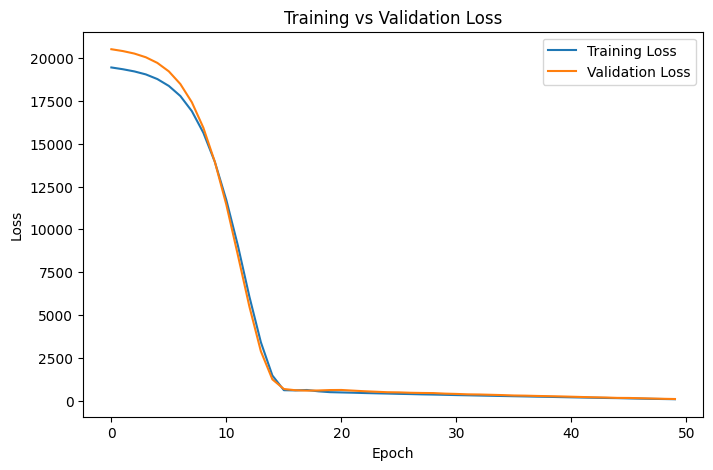

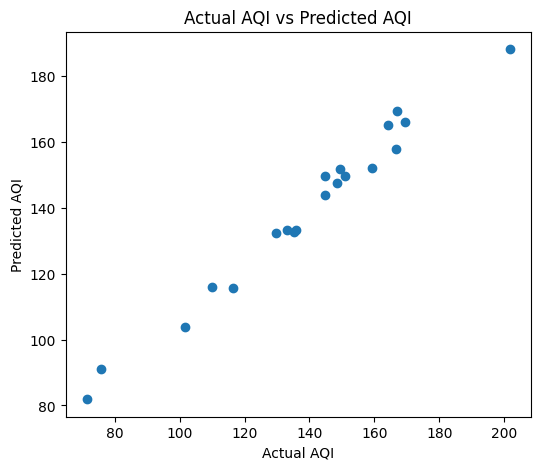


Enter Pollutant Values
PM2.5 : 10
PM10  : 10
CO    : 10
NO2   : 10
SO2   : 10
O3    : 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(



Predicted AQI = 207.73
Air Quality Category = Hazardous


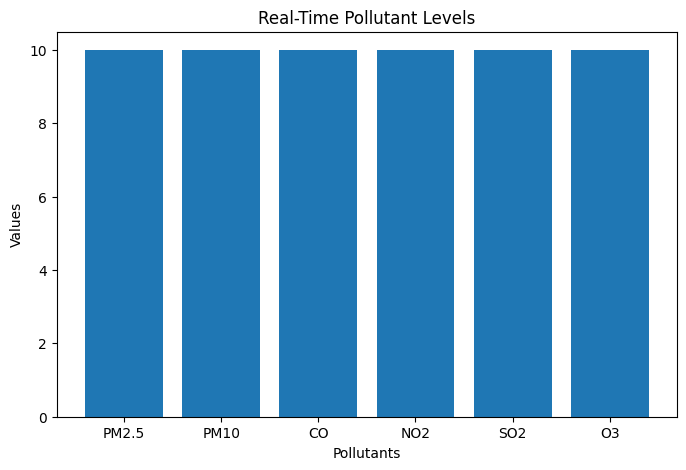

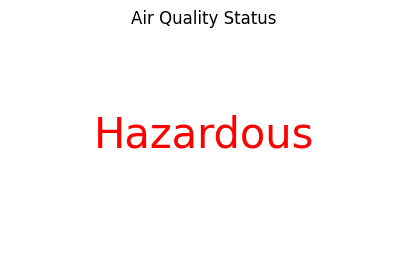


Program Executed Successfully


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ------------------------------------------
# 1. Load Dataset
# ------------------------------------------
data = pd.read_csv("/content/air_quality_100_rows.csv")

print("Dataset Loaded Successfully")
print("\nFirst 5 Records:")
print(data.head())

# ------------------------------------------
# 2. Feature Selection
# ------------------------------------------
X = data[['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3']]
y = data['AQI']

# ------------------------------------------
# 3. Data Normalization
# ------------------------------------------
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# ------------------------------------------
# 4. Train-Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# 5. Build Deep Neural Network
# ------------------------------------------
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(6,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

# ------------------------------------------
# 6. Compile Model
# ------------------------------------------
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

print("\nModel Summary:")
model.summary()

# ------------------------------------------
# 7. Train Model
# ------------------------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# ------------------------------------------
# 8. Evaluate Model
# ------------------------------------------
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("\nMean Absolute Error (MAE):", round(mae, 2))

# ------------------------------------------
# 9. Training vs Validation Loss
# ------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

# ------------------------------------------
# 10. Actual vs Predicted AQI
# ------------------------------------------
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual AQI vs Predicted AQI")

plt.show()

# ------------------------------------------
# 11. User Input for AQI Prediction
# ------------------------------------------
print("\nEnter Pollutant Values")

pm25 = float(input("PM2.5 : "))
pm10 = float(input("PM10  : "))
co   = float(input("CO    : "))
no2  = float(input("NO2   : "))
so2  = float(input("SO2   : "))
o3   = float(input("O3    : "))

new_data = [[pm25, pm10, co, no2, so2, o3]]

# Scale Input
new_data_scaled = scaler.transform(new_data)

# Predict AQI
predicted_aqi = model.predict(new_data_scaled)[0][0]

print("\nPredicted AQI =", round(predicted_aqi, 2))

# ------------------------------------------
# 12. AQI Classification
# ------------------------------------------
def classify_aqi(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 200:
        return "Poor"

    else:
        return "Hazardous"

category = classify_aqi(predicted_aqi)

print("Air Quality Category =", category)

# ------------------------------------------
# 13. Pollutant Level Visualization
# ------------------------------------------
pollutants = ['PM2.5', 'PM10', 'CO', 'NO2', 'SO2', 'O3']

plt.figure(figsize=(8,5))

plt.bar(pollutants, new_data[0])

plt.title("Real-Time Pollutant Levels")
plt.xlabel("Pollutants")
plt.ylabel("Values")

plt.show()

# ------------------------------------------
# 14. AQI Status Display
# ------------------------------------------
colors = {
    "Good": "green",
    "Moderate": "yellow",
    "Poor": "orange",
    "Hazardous": "red"
}

plt.figure(figsize=(5,3))

plt.text(
    0.5,
    0.5,
    category,
    fontsize=30,
    ha='center',
    color=colors[category]
)

plt.axis('off')
plt.title("Air Quality Status")

plt.show()

print("\nProgram Executed Successfully")